# 05_cnn_conv_linear_svd— Fashion-MNIST
03でやったfc1のSVDと04でやったconv2のsvdを同時にやる

## 1. import

実験で使うライブラリと `nn_compression` の関数を読み込む。学習ループ・SVD・指標計算は Notebook 内に再定義しない。


In [2]:
# 標準ライブラリ
from __future__ import annotations
import copy
import itertools

from copy import deepcopy
from pathlib import Path
import json
import platform
import random
import sys

# データ処理・可視化
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 評価
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.preprocessing import MinMaxScaler
# ============================================================
# 【.py側をimport】元の03ではここに def / class を書いていた
# ============================================================
# SVD圧縮: 元03では SVD / devidetwolayer（現 factorize_linear_layer）/
# make_two_layer_svd_model をセル定義
from nn_compression.compression import (
    factorize_linear_layer,  # compression/mlp_svd.py（MLPの層置換）
    retained_energy,           # compression/svd.py（特異値エネルギー）
    make_two_layer_svd_model,
    SVD,
)

# データ準備: 元03では FashionMNIST / random_split / DataLoader を直書き
from nn_compression.datasets import (
    get_fashion_mnist_datasets,      # datasets/fashion_mnist.py
    make_fashion_mnist_loaders,      # 同上
    split_fashion_mnist_dataset,     # 同上
)

# 評価指標: 元03では各セルで def していた
from nn_compression.metrics import (
    accuracy_drop,           # metrics/model_comparison.py
    agreement,               # metrics/model_comparison.py
    benchmark_inference,     # metrics/model_comparison.py
    count_parameters,        # metrics/model_comparison.py
    logits_rmse,             # metrics/model_comparison.py
    parameters_reduction,    # metrics/model_comparison.py
    compressed_linear_macs,
    linear_macs
)

# モデル: 元03では class MNISTMLP(nn.Module): をNotebook内に書いていた
from nn_compression.models import MNISTMLP  # models/mlp.py

# Pareto / knee: 元03では GetPoint などをセル定義していた
# .py化に合わせて、Python標準の snake_case 名へ整理している
from nn_compression.selection import (
    extract_pareto_frontier, # selection/pareto.py
    find_knee_point,         # selection/knee.py
    get_first_point,         # selection/knee.py
    line_equation,           # selection/knee.py
)

# 学習: 元03では train_one_epoch / evaluate / Early Stoppingループを直書き
from nn_compression.training import (
    evaluate,                 # training/loops.py
    train_one_epoch,          # training/loops.py
    fit_with_early_stopping,  # training/fit.py（Early Stopping付き学習）
)

# パス・seed: 元03では find_project_root / set_seed をNotebook内に定義
from nn_compression.utils import (
    find_project_root,     # utils/paths.py
    get_experiment_dirs,   # utils/paths.py
    make_torch_generator,  # utils/seed.py
    set_seed,              # utils/seed.py
)

## 2. 再現性と実行デバイス

seed を 0 に固定し、CUDA / MPS / CPU から使うデバイスを決める。


In [3]:
# 再現性のため seed を固定する。MLP実験と同じ 0 にして比較しやすくする。
SEED = 0
# 【.py】utils/seed.py。Python / NumPy / PyTorch の乱数源をまとめて固定する
set_seed(SEED)

# 使えるハードウェアを優先順に選ぶ: CUDA GPU → Apple MPS → CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"device: {device}")
print(f"PyTorch: {torch.__version__}")


device: cuda
PyTorch: 2.11.0+cu128


## 3. 保存先

`get_experiment_dirs` で data / models / results をプロジェクトルート基準に作る。02 を上書きしないよう、出力先は `03_cnn_linear_svd_finetuning`。


In [4]:
# MLP実験と同じく、プロジェクトルート基準で保存先を決める
# Path(".") だと Notebook の cwd 次第で data/results がズレる
DATASET_NAME = "20_fashion_mnist"
EXPERIMENT_NAME = "05_cnn_conv_linear_svd"

project_root = find_project_root(Path.cwd())
data_dir, models_dir, results_dir = get_experiment_dirs(
    project_root,
    DATASET_NAME,
    EXPERIMENT_NAME,
)

# このNotebook内の既存変数名に合わせる
# 重み → models/..., CSV・図・metadata → results/...
checkpoint_dir = models_dir
csv_dir = results_dir
figure_dir = results_dir
metadata_dir = results_dir

print("project_root:", project_root)
print("data_dir:", data_dir)
print("models_dir:", models_dir)
print("results_dir:", results_dir)


project_root: D:\dev\nn-compression-svd-dmrg
data_dir: D:\dev\nn-compression-svd-dmrg\data
models_dir: D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\05_cnn_conv_linear_svd
results_dir: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\05_cnn_conv_linear_svd


## 4. Fashion-MNISTの読み込み

`ToTensor()` で画像を `(1, 28, 28)` のテンソルにする。公式の学習 60,000 枚を train / validation に分け、test 10,000 枚は最終評価まで使わない。


In [5]:
# 画像をPyTorchで扱える torch.Tensor に変換するための変換処理オブジェクトを作っています。
# Datasetに渡すと、各画像を取り出すたびにこの変換が適用されます。
# ToTensor(): PIL Image (28×28) → Tensor (1, 28, 28)、値域は [0, 1]
transform = transforms.ToTensor()

# 【.py】get_experiment_dirs が返した data/ を使う（cwd に依存しない）
data_root = data_dir

# train=True: 公式の学習用 60,000 枚。後で train / validation に分割する
full_train_dataset = datasets.FashionMNIST(
    root=data_root,
    train=True,
    download=True,
    transform=transform,
)

# train=False: 公式のテスト 10,000 枚。最終評価まで使わない
test_dataset = datasets.FashionMNIST(
    root=data_root,
    train=False,
    download=True,
    transform=transform,
)

train_size = 50_000
validation_size_early_stop = 5_000
validation_size_rank = 5_000

# random_split の分割結果を seed で固定する
split_generator = torch.Generator().manual_seed(SEED)

train_dataset, validation_dataset_early_stop,validation_dataset_rank = random_split(
    full_train_dataset,
    lengths=[train_size, validation_size_early_stop,validation_size_rank],
    generator=split_generator,
)

print(f"train:      {len(train_dataset):,}")
print(f"validation_early_stop: {len(validation_dataset_early_stop):,}")
print(f"validation_rank: {len(validation_dataset_rank):,}")
print(f"test:       {len(test_dataset):,}")


train:      50,000
validation_early_stop: 5,000
validation_rank: 5,000
test:       10,000


## 5. DataLoader

batch size 256、`num_workers=0` で学習・Early Stopping 用 validation・rank 比較用 validation・test のローダを作る。`train_loader` を `next(iter(...))` すると shuffle 用 Generator を消費するので、shape 確認は `train_dataset[0]` で行う。


In [6]:
BATCH_SIZE = 256
# データを読む・画像変換する・バッチ化するための子プロセス数です。
#0：メインプロセス自身がデータを読み込む。デバッグしやすく、Windows/Jupyterで問題を切り分けやすい
#1 以上：複数の子プロセスが次のバッチを並列に準備するため、ディスクI/Oや画像拡張が重い場合に学習待ち時間を減らせる
#増やしすぎると、CPU競合・メモリ使用量増加・プロセス起動のオーバーヘッドで、かえって遅くなることがある
#num_workers はGPU数ではなく、CPU側のデータ準備担当者の人数です。
# まず 0 で正しく動作を確認し、2, 4, 8 などを実測して、1 epochあたりの時間が最短になる値を選ぶのが確実です。
NUM_WORKERS = 0

loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    #num_workers は、DataLoaderがデータを読み込み・前処理・バッチ化するために使う子プロセスの数です。
    # 大きくすると、次のバッチを並列に準備できるため、GPUがデータ待ちになる時間を減らせる場合があります。
    num_workers=NUM_WORKERS,
    # CUDA GPUを使うときだけ True にする設定です。
    # True なら、DataLoaderが返すCPUテンソルをページロック（pinned）メモリに置き、
    # CPUからGPUへの転送を速くしやすくします。
    # CPU側の転送用メモリを固定する設定です。
    # 小さなデータやCPU学習では効果が乏しく、ホストメモリの負担もあるため、CUDA時だけ有効にする現在の書き方がよいです。
    pin_memory=(device.type == "cuda"),
    # shuffle=True で使うランダムなデータ順序を制御する torch.Generator です。
    # 通常は再現性のためにシード固定済みのジェネレータを渡します。
    generator=loader_generator,
)

validation_loader_early_stop = DataLoader(
    validation_dataset_early_stop,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

validation_loader_rank = DataLoader(
    validation_dataset_rank,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

# train_loader を next(iter(...)) すると shuffle 用 Generator を消費するので避ける
image, label = train_dataset[0]
print(f"image shape: {tuple(image.shape)}")
print(f"label: {label}")
print(f"batch images shape: ({BATCH_SIZE}, {image.shape[0]}, {image.shape[1]}, {image.shape[2]})")


image shape: (1, 28, 28)
label: 6
batch images shape: (256, 1, 28, 28)


## 6. CNNモデルの定義

Conv2d → ReLU → MaxPool を2回したあと Flatten し、`Linear(3136, 128)` → `Linear(128, 10)` で分類する。次の SVD 対象は後段の `conv2`。


In [7]:
class FashionMNISTCNN(nn.Module):
    """Fashion-MNIST分類用CNN。"""
    
    #def 関数名(引数) -> 戻り値の型:
    def __init__(self) -> None:
        super().__init__()

        # 最初の畳み込み層を定義する。
        # 前のモデル構成と Conv2d の引数を対応させて考える。
        #nn.Conv1d、nn.Conv2d、nn.Conv3d の違いは、
        # 畳み込みフィルタを何次元方向にスライドさせるかです。
        # チャネル数の次元は別物で、1d / 2d / 3d は「畳み込む空間・時間方向の数」を表します。
        self.conv1 = nn.Conv2d(
            # 最初の画像のチャネル数、Fashion-MNISTはグレースケールだから1
            in_channels=1,
            # 何個フィルターを用意するか
            out_channels=32,
            # フィルターのサイズ
            kernel_size=3,
            # フィルターの動かし幅
            stride=1,
            # 上下左右に足すパディング幅
            padding=1
        )

        # ReLU: 非線形。無いと畳み込みを重ねても表現力が弱い
        self.relu1 = nn.ReLU()
        # 2×2 MaxPool。stride=2 なので縦横が半分（28 → 14）
        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        self.conv2 = nn.Conv2d(
            # 前層のout_channel
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.relu2 = nn.ReLU()
        # もう一度半分（14 → 7）。Flatten直前は 64×7×7
        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        # (N, 64, 7, 7) → (N, 3136)。以降は全結合層で分類する
        self.flatten = nn.Flatten()

        # Flatten後の特徴数を計算して、hidden層へ接続する。
        # inspect_shapes() で次元を確認してから埋める。
        self.fc1 = nn.Linear(
             in_features=3136,  # 例: 64 × 7 × 7
             out_features=128)
        #self.fc1 = None
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(
            in_features=128,
            # 最終的に10クラスに分類するから
            out_features=10
        )
        #self.fc2 = None

# ------------------------------------------------------------
# inspect_shapes の使い方
# ------------------------------------------------------------
# FashionMNISTCNN.inspect_shapes() は、各層の出力shapeを表示し、
# Flatten後の特徴数（Linear の in_features）を返す確認用メソッド。
#
# 基本（引数なし）:
#   ダミー入力 (1, 1, 28, 28) で確認する。train_loader は触らない。
#
# model = FashionMNISTCNN()
# flatten_dim = model.inspect_shapes()
#
# 出力例:
#   input:         (1, 1, 28, 28)
#   after conv1:   (1, 32, 28, 28)
#   after pool1:   (1, 32, 14, 14)
#   after conv2:   (1, 64, 14, 14)
#   after pool2:   (1, 64, 7, 7)
#   after flatten: (1, 3136)
#   flatten_dim:   3136
#
# 返ってきた flatten_dim を Linear に使う:
# model.fc1 = nn.Linear(in_features=flatten_dim, out_features=128)
# model.fc2 = nn.Linear(in_features=128, out_features=10)
#
# 実画像で確認したい場合:
# image, label = train_dataset[0]    # (1, 28, 28)
# x = image.unsqueeze(0)             # (1, 1, 28, 28)
# flatten_dim = model.inspect_shapes(x)

    def inspect_shapes(
        self,
        x: torch.Tensor | None = None,
    ) -> int:
        """各層の出力shapeを表示し、Flatten後の特徴数を返す。

        Linear の in_features が不明なときに使う確認用メソッド。
        train_loader は消費しない。
        """
        if x is None:
            x = torch.zeros(1, 1, 28, 28)

        print("input:        ", tuple(x.shape))
        x = self.conv1(x)
        print("after conv1:  ", tuple(x.shape))
        x = self.relu1(x)
        x = self.pool1(x)
        print("after pool1:  ", tuple(x.shape))
        x = self.conv2(x)
        print("after conv2:  ", tuple(x.shape))
        x = self.relu2(x)
        x = self.pool2(x)
        print("after pool2:  ", tuple(x.shape))
        x = self.flatten(x)
        print("after flatten:", tuple(x.shape))

        flatten_dim = x.shape[1]
        print("flatten_dim:  ", flatten_dim)
        return flatten_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 特徴抽出: Conv → ReLU → Pool を2回
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.flatten(x)
        # return x
        # 次元が分かったら Linear を埋めて、続きを実装する:
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        return x

## 7. 総パラメータ数

CNN をデバイスへ載せ、学習可能な重みの総数を数える。この設計なら 421,642 になる。


In [8]:
baseline_model = FashionMNISTCNN().to(device)
# 【.py】metrics/model_comparison.py。学習可能・非学習可能を問わず全要素数を数える
baseline_parameter_count = count_parameters(
    baseline_model
)

print(f"parameters: {baseline_parameter_count:,}")

# モデルを上の設計通りに書けていれば421,642になる。
assert baseline_parameter_count == 421_642


parameters: 421,642


## 8. 層ごとのパラメータ数

`named_parameters()` で各層の shape と要素数を出し、`fc1` が大きいことを確認する。


In [9]:
# 各層のパラメータ数も確認する。
#named_parameters() は、
# PyTorchモデルの学習対象パラメータを
# 「名前」と「Tensor」の組で取り出すメソッドです。
# numel(): その Tensor の要素数 = その層のパラメータ数
for name, parameter in baseline_model.named_parameters():
    print(
        f"{name:20s} "
        f"shape={str(tuple(parameter.shape)):18s} "
        f"params={parameter.numel():,}"
    )


conv1.weight         shape=(32, 1, 3, 3)      params=288
conv1.bias           shape=(32,)              params=32
conv2.weight         shape=(64, 32, 3, 3)     params=18,432
conv2.bias           shape=(64,)              params=64
fc1.weight           shape=(128, 3136)        params=401,408
fc1.bias             shape=(128,)             params=128
fc2.weight           shape=(10, 128)          params=1,280
fc2.bias             shape=(10,)              params=10


## 9. Baseline学習

多クラス分類なので `CrossEntropyLoss` と Adam を使い、Early Stopping 付きで Baseline CNN を学習する。


In [10]:
# 多クラス分類なので CrossEntropyLoss
# （内部で log_softmax + NLLLoss をやるので、モデル出力は logits のまま）
criterion = nn.CrossEntropyLoss()

BASELINE_LEARNING_RATE = 1e-3
BASELINE_EPOCHS = 30
PATIENCE=3
MIN_DELTA = 1e-4

# Adam: 学習率 0.001 はよく使う初期値
optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=BASELINE_LEARNING_RATE,
)

baseline_fit = fit_with_early_stopping(
    baseline_model,
    train_loader,
    validation_loader_early_stop,
    criterion,
    optimizer,
    device,
    BASELINE_EPOCHS,
    PATIENCE,
    MIN_DELTA,
)

Early stopping at epoch 18


## 10. 学習履歴の保存

最良 epoch と validation loss を確認し、`fit_history.csv` と `fit_loss_history.csv` に書き出す。


In [11]:
# fit_with_early_stopping の学習履歴。CSV保存とグラフ用に取り出す
history = baseline_fit["history"]
train_loss_history = baseline_fit["train_loss_history"]
validation_loss_history = baseline_fit["validation_loss_history"]
best_epoch = baseline_fit["best_epoch"]
best_validation_loss = baseline_fit["best_validation_loss"]
df_training_history = pd.DataFrame(history)

print()
print(f"best epoch: {best_epoch}")
print(
    "best validation loss: "
    f"{best_validation_loss:.4f}"
)
print(f"epochs recorded: {len(history)}")

# epochごとの詳細履歴（loss / acc）
history_csv = csv_dir / "fit_history.csv"
df_training_history.to_csv(history_csv, index=False)

# 戻り値の1次元リストも保存しておく
loss_history_csv = csv_dir / "fit_loss_history.csv"
pd.DataFrame(
    {
        "epoch": list(range(1, len(train_loss_history) + 1)),
        "train_loss": train_loss_history,
        "validation_loss": validation_loss_history,
    }
).to_csv(loss_history_csv, index=False)

print("saved:", history_csv)
print("saved:", loss_history_csv)



best epoch: 15
best validation loss: 0.2118
epochs recorded: 18
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\05_cnn_conv_linear_svd\fit_history.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\05_cnn_conv_linear_svd\fit_loss_history.csv


## 11. 学習曲線

履歴を表で表示し、loss / accuracy の epoch 推移を描く。最良重みの `state_dict` も控えておく。


Best epoch: 15
Best validation loss: 0.2118


,epoch,train_acc,train_loss,validation_loss,validation_acc
0,1,0.84964,0.418617,0.428412,0.8436
1,2,0.87994,0.336759,0.346146,0.8728
2,3,0.89324,0.297944,0.311885,0.8818
3,4,0.90096,0.274460,0.284831,0.8924
4,5,0.91546,0.236532,0.262072,0.9028
5,6,0.91900,0.226321,0.253714,0.9046
6,7,0.92140,0.216312,0.247131,0.9106
7,8,0.93026,0.193128,0.238698,0.9094
8,9,0.93386,0.183458,0.231532,0.9124
9,10,0.93854,0.171534,0.236342,0.9134


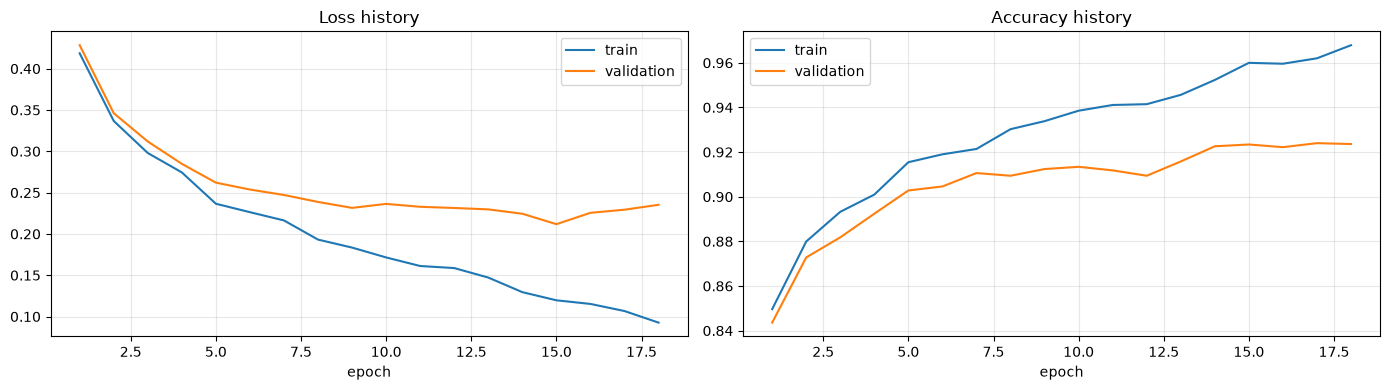

In [12]:
from IPython.display import display

model = baseline_fit["model"]
baseline_state = copy.deepcopy(model.state_dict())

# 【.ipynb側】履歴を DataFrame / グラフにするのは実験ノートの仕事
df_training_history = pd.DataFrame(baseline_fit["history"])

print("Best epoch:", baseline_fit["best_epoch"])
print(f"Best validation loss: {baseline_fit['best_validation_loss']:.4f}")
display(df_training_history)

fig_learning, axes_learning = plt.subplots(1, 2, figsize=(14, 4))
axes_learning[0].plot(df_training_history["epoch"], df_training_history["train_loss"], label="train")
axes_learning[0].plot(df_training_history["epoch"], df_training_history["validation_loss"], label="validation")
axes_learning[0].set_title("Loss history")
axes_learning[0].set_xlabel("epoch")
axes_learning[0].legend()
axes_learning[0].grid(True, alpha=0.3)

axes_learning[1].plot(df_training_history["epoch"], df_training_history["train_acc"], label="train")
axes_learning[1].plot(df_training_history["epoch"], df_training_history["validation_acc"], label="validation")
axes_learning[1].set_title("Accuracy history")
axes_learning[1].set_xlabel("epoch")
axes_learning[1].legend()
axes_learning[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. MACsの見積もり

`conv2` を `kH×kW Conv(in → rank)` + `1×1 Conv(rank → out)` に分解したときの MACs と削減率を、元の Conv2d と比較して出す。この CNN では pool1 後が 14×14 で、`conv2` の出力も 14×14 になる。


In [ ]:
def conv2d_macs(conv, out_h, out_w):
    """1サンプルが Conv2d を通るときの MACs を返す。

    出力の各位置・各チャネルが ``in_ch * kH * kW`` 回の積和をするので
    ``out_h * out_w * out_ch * in_ch * kH * kW``。
    """
    out_ch, in_ch, k_h, k_w = conv.weight.shape
    return out_h * out_w * out_ch * in_ch * k_h * k_w // conv.groups


def compressed_conv2d_macs(conv, rank, out_h, out_w):
    """``factorize_Conv2d_layer`` と同じ2層Convの MACs を返す。

    1層目: ``Conv(in -> rank, kH x kW)``
    2層目: ``Conv(rank -> out, 1x1)``
    空間サイズは分解前の出力と同じ。
    """
    out_ch, in_ch, k_h, k_w = conv.weight.shape
    first_layer_macs = out_h * out_w * rank * in_ch * k_h * k_w
    second_layer_macs = out_h * out_w * out_ch * rank
    return first_layer_macs + second_layer_macs


def estimate_macs_conv2(model, conv2_rank, verbose=True):
    """conv2 だけを SVD 分解したときの MACs・削減率を比較する。

    conv2 の入力は pool1 後の 14x14。padding=1, stride=1 なので
    出力も 14x14。他層は圧縮しないので、比較対象は conv2 だけにする。
    """
    conv2_out_h, conv2_out_w = 14, 14
    baseline_macs = conv2d_macs(model.conv2, conv2_out_h, conv2_out_w)
    compressed_macs = compressed_conv2d_macs(
        model.conv2,
        conv2_rank,
        conv2_out_h,
        conv2_out_w,
    )
    compute_reduction_rate = 1.0 - compressed_macs / baseline_macs

    if verbose:
        print("Baseline MACs:", baseline_macs)
        print("Compressed MACs:", compressed_macs)
        print(f"Compute reduction: {compute_reduction_rate:.2%}")

    return baseline_macs, compressed_macs, compute_reduction_rate


In [14]:
import torch
import torch.nn as nn


def factorize_Conv2d_layer(
    conv: nn.Conv2d,
    rank: int,
) -> nn.Sequential:
    """
    Conv2dをSVDで低ランクな2層Convへ分解する。

    W.shape     : (out_ch, in_ch, kH, kW)
    W_mat.shape : (out_ch, in_ch * kH * kW)

    W_mat ≈ B @ A
      A = Vh_r                 : (rank, in_ch * kH * kW)
          -> 1層目の kHxkW Conv。入力からrank個の中間特徴量を作る。

      B = U_r @ diag(S_r)      : (out_ch, rank)
          -> 2層目の 1x1 Conv。rank個の中間特徴量を混合して
             元のout_ch個の出力特徴量を作る。

    Conv重みは出力チャネルごとに先頭次元へ積まれるため、
    Bの各行は「1つの最終出力チャネル」を作る混合係数になる。
    """
    if conv.groups != 1:
        raise ValueError("groups=1 のConv2dのみ対応しています。")

    out_ch, in_ch, k_h, k_w = conv.weight.shape
    max_rank = min(out_ch, in_ch * k_h * k_w)
    if not 1 <= rank <= max_rank:
        raise ValueError(f"rank は1〜{max_rank}の範囲で指定してください。")
    
    # Conv重みをSVD用の2次元行列へ変換:
    # (out_ch, in_ch, kH, kW) -> (out_ch, in_ch * kH * kW)
    W_mat = conv.weight.detach().flatten(start_dim=1)

    # 上位rank個の特異値・特異ベクトルだけを使う。
    #U_r[:, :rank]      # (out_ch, rank)
    #S_r [:rank]         # (rank,)
    #Vh_r[:rank, :]    # (rank, in_ch * kH * kW)
    # W_mat = U @ diag(S) @ Vh
    U_r, S_r, Vh_r = SVD(W_mat, rank)
  
    # W_mat ≈ B @ A
    A = Vh_r                          # 1層目用
    B = U_r @ torch.diag(S_r)         # 2層目用

    # Aを (rank, in_ch, kH, kW) に戻して通常の畳み込みへ使う。
    first_layer = nn.Conv2d(
        in_channels=conv.in_channels,
        out_channels=rank,
        kernel_size=conv.kernel_size,
        stride=conv.stride,
        padding=conv.padding,
        dilation=conv.dilation,
        bias=False,
    )

    # Bを (out_ch, rank, 1, 1) にして、位置ごとのチャネル混合を行う。
    # 1×1 / stride=1 / padding=0 により空間サイズは変えない。
    second_layer = nn.Conv2d(
        in_channels=rank,
        out_channels=conv.out_channels,
        kernel_size=1,
        stride=1,
        padding=0,
        bias=(conv.bias is not None),
    )

    with torch.no_grad():
        first_layer.weight.copy_(
            A.reshape(rank, in_ch, k_h, k_w)
        )
        second_layer.weight.copy_(
            B.reshape(out_ch, rank, 1, 1)
        )

        # 元のbiasは最終出力に加わるため2層目へ移す。
        if conv.bias is not None:
            second_layer.bias.copy_(conv.bias)

    return nn.Sequential(first_layer, second_layer).to(
        device=conv.weight.device,
        dtype=conv.weight.dtype,
    )

In [15]:
def factorize_named_linear(model, layer_name, rank):
    """指定した Linear 層だけを rank の2層に置換したコピーを返す。

    ``Linear(in -> out)`` を ``Linear(in -> rank)`` + ``Linear(rank -> out)``
    に分解する。CNN なら ``layer_name="fc1"`` のように、SVDしたい層の
    属性名を文字列で渡す。

    元の model は変更しない。MNISTMLP は作らず、渡されたモデルをコピーする。
    """
    compressed_model = copy.deepcopy(model)
    layer = getattr(compressed_model, layer_name)
    setattr(
        compressed_model,
        layer_name,
        factorize_linear_layer(layer, rank),
    )
    return compressed_model


# 使い方:
# compressed_model = one_layer_svd_model(model, "fc1", rank=64)
# fc2 を圧縮したいとき:
# compressed_model = one_layer_svd_model(model, "fc2", rank=8)


In [17]:
def estimate_macs_fc1(model,fc1_rank, verbose=True):
    """現在の MLP と SVD 圧縮版の MACs・削減率を比較する。

    ``fc1`` と ``fc2`` は低ランク2層へ置換済み、``fc3`` は元の Linear
    のまま、という元Notebookと同じ前提で計算する。
    """
    baseline_macs = (
        linear_macs(model.fc1)
        + linear_macs(model.fc2)
    )

    compressed_macs = (
        compressed_linear_macs(model.fc1.weight.shape[0],model.fc1.weight.shape[1], fc1_rank)
        + linear_macs(model.fc2)
    )
    compute_reduction_rate = 1.0 - compressed_macs / baseline_macs

    if verbose:
        print("Baseline MACs:", baseline_macs)
        print("Compressed MACs:", compressed_macs)
        print(f"Compute reduction: {compute_reduction_rate:.2%}")

    return baseline_macs, compressed_macs, compute_reduction_rate

In [22]:
def estimate_macs(
    model,
    conv2_rank,
    fc1_rank,
    verbose=True,
):
    conv1_macs = conv2d_macs(
        model.conv1, 28, 28
    )

    conv2_baseline_macs = conv2d_macs(
        model.conv2, 14, 14
    )
    conv2_compressed_macs = compressed_conv2d_macs(
        model.conv2,
        conv2_rank,
        14,
        14,
    )

    fc1_baseline_macs = linear_macs(model.fc1)
    fc1_compressed_macs = compressed_linear_macs(
        model.fc1.in_features,
        model.fc1.out_features,
        fc1_rank,
    )

    fc2_macs = linear_macs(model.fc2)

    baseline_macs = (
        conv1_macs
        + conv2_baseline_macs
        + fc1_baseline_macs
        + fc2_macs
    )

    compressed_macs = (
        conv1_macs
        + conv2_compressed_macs
        + fc1_compressed_macs
        + fc2_macs
    )

    reduction = 1.0 - compressed_macs / baseline_macs

    if verbose:
        print("Baseline total MACs:", baseline_macs)
        print("Compressed total MACs:", compressed_macs)
        print(f"Compute reduction: {reduction:.2%}")

    return baseline_macs, compressed_macs, reduction

## 14. SVD rank sweep

`conv` の rank 候補を走査し、圧縮直後（未学習）の validation loss / acc、パラメータ削減、agreement などを表にまとめる。


In [23]:
CONV2_RANK = 28
FC1_RANK=24


# 【.py】metrics/model_comparison.py / metrics/mlp_macs.py
baseline_time_s = benchmark_inference(
    model,
    validation_loader_rank,
    device,
    warmup=20,    # 【.ipynb】ベンチ条件
    repeats=2000, # 【.ipynb】ベンチ条件
)
# 【.py】training/loops.py
baseline_rank_validation_loss, baseline_rank_validation_acc = evaluate(
    model,
    validation_loader_rank,
    criterion,
    device,
)

rank_results = []

compressed_model = copy.deepcopy(model)

# CONV2のSVD
New_Conv2 = factorize_Conv2d_layer(
    model.conv2,
    CONV2_RANK,
)

# FC1のSVD
compressed_model = factorize_named_linear(
    model,
    "fc1",
    FC1_RANK,
)

compressed_model.conv2=New_Conv2

validation_loss, validation_acc = evaluate(
    compressed_model,
    validation_loader_rank,
    criterion,
    device,
)

# 【.py】metrics/*
drop = accuracy_drop(
    baseline_rank_validation_acc,
    validation_acc,
    verbose=False,
)


_, compressed_macs, compute_reduction = estimate_macs(
    model,
    CONV2_RANK,
    FC1_RANK,
    verbose=False,
)


compressed_time_s = benchmark_inference(
    compressed_model,
    validation_loader_rank,
    device,
    warmup=5,
    repeats=200,
)

    # 【.ipynb側】どの列を結果表に入れるかは実験設計
row = {
    "conv2_rank": CONV2_RANK,
    "parameters": count_parameters(compressed_model),
    "parameters_reduction": parameters_reduction(model, compressed_model),
    "validation_loss": validation_loss,
    "validation_acc": validation_acc,
    "accuracy_drop": drop,
    "compressed_macs": compressed_macs,
    "compute_reduction": compute_reduction,
    "baseline_time_ms": baseline_time_s * 1000,
    "compressed_time_ms": compressed_time_s * 1000,
    "agreement": agreement(model, compressed_model, validation_loader_rank, device),
    "logits_rmse": logits_rmse(model, compressed_model, validation_loader_rank, device),
    "retained_energy_conv2": retained_energy(model.conv2, CONV2_RANK),
    "model": compressed_model,
}
rank_results.append(row)
print(
    f"r1={CONV2_RANK:3d}| "
    f"Acc={validation_acc:.4f} loss={validation_loss:.4f} | "
    f"params={row['parameters']} MACs={compressed_macs} | "
    f"agreement={row['agreement']:.4f}"
)

print(f"\n集計完了: {len(rank_results)} 件")

r1= 28| Acc=0.9124 loss=0.2464 | params=89994 MACs=2237184 | agreement=0.9674

集計完了: 1 件


## 17. Fine-tuning（knee ±1）

SVD 圧縮した候補ごとに optimizer と seed を作り直し、Early Stopping で Fine-tuning する。構造が変わっているので optimizer は使い回さない。


In [24]:

fine_tuned_records = []
LEARNING_RATE=3e-4
MAX_EPOCHS = 30


fine_tuned_model = copy.deepcopy(compressed_model).to(device)

# 【.ipynb側】候補ごとに optimizer を作り直す（元03と同じ注意点）
# SVDする前は1層を2層Conv2dにしてなくて、SVD後はするから、
# 構造が違うから、optimzerを作り直す
candidate_optimizer = torch.optim.Adam(
    fine_tuned_model.parameters(),
    lr=LEARNING_RATE,
)
# 各候補を同じ乱数条件・同じshuffle順で比較する
set_seed(SEED)
loader_generator.manual_seed(SEED)
print(f"\n=== fine-tune conv2={CONV2_RANK} ===")
print(f"\n=== fine-tune fc1={FC1_RANK} ===")

# 【.py】training/fit.py を baseline 学習と同じく再利用
fit_result = fit_with_early_stopping(
    model=fine_tuned_model,
    train_loader=train_loader,
    val_loader=validation_loader_early_stop,  # Early Stopping用（rank用ではない）
    criterion=criterion,
    optimizer=candidate_optimizer,
    device=device,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
)

fine_tuned_records.append(
    {
        "fc1_rank": FC1_RANK,
        "conv2_rank": CONV2_RANK,
        "best_epoch": fit_result["best_epoch"],
        "best_validation_loss": fit_result["best_validation_loss"],
        "history": fit_result["history"],
        "model": fit_result["model"],
    }
)

df_fine_tuned_models = pd.DataFrame(fine_tuned_records)
display(df_fine_tuned_models.drop(columns=["history", "model"]))


=== fine-tune conv2=28 ===

=== fine-tune fc1=24 ===
Early stopping at epoch 4


,fc1_rank,conv2_rank,best_epoch,best_validation_loss
0,24,28,1,0.220585


## 18. Fine-tuning前後の比較

この Notebook の圧縮設定は `conv2` と `fc1` の1組だけなので、候補ラベル（Aggressive / Balanced / Conservative）は使わない。同じ `validation_loader_rank` で、SVD 直後と Fine-tuning 後の acc / loss を比較する。


=== FT前後  conv2=28, fc1=24 ===
acc:  0.9124 -> 0.9204  (delta=+0.0080)
loss: 0.2464 -> 0.2221  (delta=-0.0243)


,candidate,conv2_rank,fc1_rank,acc_before,acc_after,delta_acc,loss_before,loss_after,delta_loss
0,"conv2=28, fc1=24",28,24,0.9124,0.9204,0.008,0.246371,0.222078,-0.024293


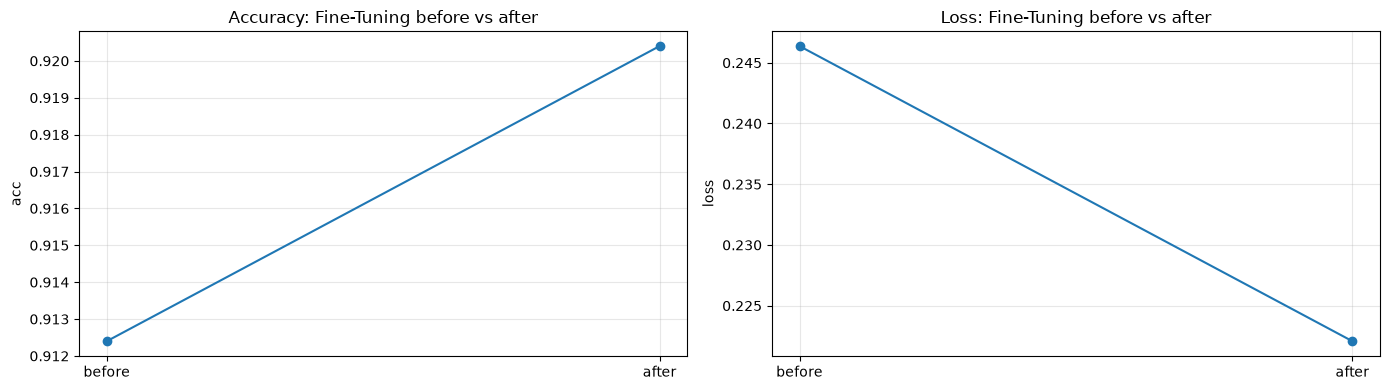

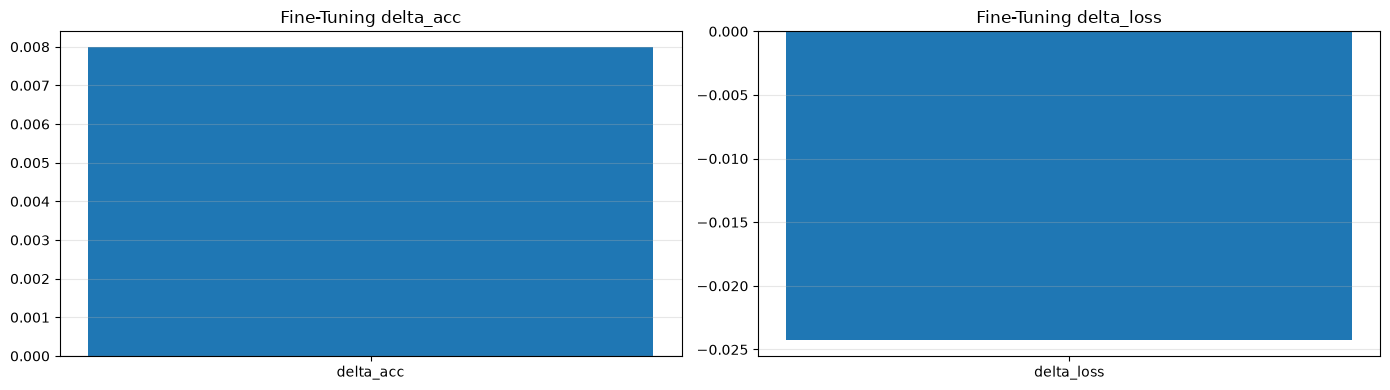

In [25]:
# ============================================================
# 【.ipynb側】Fine-tuning 前後の比較表・グラフ（実験固有）
# 【.py側】evaluate だけ再利用
# ============================================================
fine_tuning_records = []

matched = df_fine_tuned_models[
    (df_fine_tuned_models["conv2_rank"] == CONV2_RANK)
    & (df_fine_tuned_models["fc1_rank"] == FC1_RANK)
]
if len(matched) != 1:
    raise ValueError(
        "Fine-tuning済みモデルが一意に見つかりません: "
        f"conv2={CONV2_RANK}, fc1={FC1_RANK}, matches={len(matched)}"
    )

# before: SVD直後（未学習）。FTセルは deepcopy するので compressed_model は変えない
loss_before, acc_before = evaluate(
    compressed_model,
    validation_loader_rank,
    criterion,
    device,
)
loss_after, acc_after = evaluate(
    matched.iloc[0]["model"],
    validation_loader_rank,
    criterion,
    device,
)

print(f"=== FT前後  conv2={CONV2_RANK}, fc1={FC1_RANK} ===")
print(f"acc:  {acc_before:.4f} -> {acc_after:.4f}  (delta={acc_after - acc_before:+.4f})")
print(f"loss: {loss_before:.4f} -> {loss_after:.4f}  (delta={loss_after - loss_before:+.4f})")

fine_tuning_records.append(
    {
        "candidate": f"conv2={CONV2_RANK}, fc1={FC1_RANK}",
        "conv2_rank": CONV2_RANK,
        "fc1_rank": FC1_RANK,
        "acc_before": acc_before,
        "acc_after": acc_after,
        "delta_acc": acc_after - acc_before,
        "loss_before": loss_before,
        "loss_after": loss_after,
        "delta_loss": loss_after - loss_before,
    }
)

df_fine_tuning_result = pd.DataFrame(fine_tuning_records)
display(df_fine_tuning_result)

stages = ["before", "after"]
fig_delta, axes_delta = plt.subplots(1, 2, figsize=(14, 4))
axes_delta[0].plot(stages, [acc_before, acc_after], marker="o")
axes_delta[0].set_title("Accuracy: Fine-Tuning before vs after")
axes_delta[0].set_ylabel("acc")
axes_delta[0].grid(True, alpha=0.3)
axes_delta[1].plot(stages, [loss_before, loss_after], marker="o")
axes_delta[1].set_title("Loss: Fine-Tuning before vs after")
axes_delta[1].set_ylabel("loss")
axes_delta[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig_after, axes_after = plt.subplots(1, 2, figsize=(14, 4))
axes_after[0].bar(["delta_acc"], [acc_after - acc_before])
axes_after[0].axhline(0.0, color="gray", linewidth=0.8)
axes_after[0].set_title("Fine-Tuning delta_acc")
axes_after[0].grid(True, axis="y", alpha=0.3)
axes_after[1].bar(["delta_loss"], [loss_after - loss_before])
axes_after[1].axhline(0.0, color="gray", linewidth=0.8)
axes_after[1].set_title("Fine-Tuning delta_loss")
axes_after[1].grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 19. 最終モデル選択と Test 評価

Fine-tuning 後の から最終1モデルを選び、ここで初めて test を Baseline と比較する。


In [19]:
# ============================================================
# 【.ipynb側】比較表の組み立て・最終選択ルール
# 【.py側】extract_pareto_frontier / evaluate / count_parameters を再利用
# ============================================================
df_candidate_params = df_pareto_best[
    ["conv2_rank", "parameters", "parameters_reduction"]
].copy()
df_after_comparison = df_fine_tuning_result.merge(
    df_candidate_params,
    on=["conv2_rank"],
    how="left",
    validate="one_to_one",
)

comparison_records = [
    {
        "model": "Baseline",
        "conv2_rank": "-",
        "validation_acc": baseline_rank_validation_acc,
        "validation_loss": baseline_rank_validation_loss,
        "parameters": baseline_params,
        "parameters_reduction": 0.0,
    }
]
for _, row in df_after_comparison.iterrows():
    comparison_records.append(
        {
            "model": f"{row['candidate']} after FT",
            "conv2_rank": int(row["conv2_rank"]),
            "validation_acc": row["acc_after"],
            "validation_loss": row["loss_after"],
            "parameters": int(row["parameters"]),
            "parameters_reduction": row["parameters_reduction"],
        }
    )

df_model_comparison = pd.DataFrame(comparison_records)
display(df_model_comparison)

# Baselineは圧縮モデルの選択対象から除外
df_final_candidates = df_model_comparison[
    df_model_comparison["model"] != "Baseline"
].copy()

# 【.py】selection/pareto.py を再度利用
df_final_pareto = extract_pareto_frontier(
    df_final_candidates,
    x_column="parameters",
    y_column="validation_loss",
)

# 【.ipynb側】最終1モデルの優先順位（元03と同じ）
df_final_pareto = df_final_pareto.sort_values(
    by=["validation_loss", "parameters", "validation_acc"],
    ascending=[True, True, False],
).reset_index(drop=True)

final_model_result = df_final_pareto.iloc[0]
final_conv2_rank = int(final_model_result["conv2_rank"])
final_model = df_fine_tuned_models.loc[
    (df_fine_tuned_models["conv2_rank"] == final_conv2_rank),
    "model",
].iloc[0]

print("Selected final model:")
display(df_final_pareto.iloc[[0]])
print(f"Final model: r1={final_conv2_rank}")

# 最終選択後にTestを評価
final_test_loss, final_test_acc = evaluate(
    final_model,
    test_loader,
    criterion,
    device,
)
baseline_model_for_test = FashionMNISTCNN().to(device)
baseline_model_for_test.load_state_dict(baseline_state)
baseline_test_loss, baseline_test_acc = evaluate(
    baseline_model_for_test,
    test_loader,
    criterion,
    device,
)

df_test_comparison = pd.DataFrame(
    [
        {
            "model": "Baseline",
            "conv2_rank": "-",
            "parameters": baseline_params,
            "test_loss": baseline_test_loss,
            "test_acc": baseline_test_acc,
            "delta_test_acc": 0.0,
            "delta_test_loss": 0.0,
        },
        {
            "model": "Final (compressed + FT)",
            "conv2_rank": final_conv2_rank,
            "parameters": count_parameters(final_model),
            "test_loss": final_test_loss,
            "test_acc": final_test_acc,
            "delta_test_acc": final_test_acc - baseline_test_acc,
            "delta_test_loss": final_test_loss - baseline_test_loss,
        },
    ]
)
display(df_test_comparison)

,model,conv2_rank,validation_acc,validation_loss,parameters,parameters_reduction
0,Baseline,-,0.9254,0.215624,421642,0.000000
1,Aggressive after FT,24,0.9250,0.210216,411658,0.023679
2,Balanced after FT,28,0.9260,0.209334,413066,0.020340
3,Conservative after FT,32,0.9240,0.209582,414474,0.017000


Selected final model:


,model,conv2_rank,validation_acc,validation_loss,parameters,parameters_reduction
0,Balanced after FT,28,0.926,0.209334,413066,0.02034


Final model: r1=28


,model,conv2_rank,parameters,test_loss,test_acc,delta_test_acc,delta_test_loss
0,Baseline,-,421642,0.234131,0.9175,0.0000,0.000000
1,Final (compressed + FT),28,413066,0.236488,0.9197,0.0022,0.002358


## 20. 結果の保存

Fine-tuning 結果、Test 比較、最終モデルの重みを `04_cnn_conv_svd` へ保存する。CSV の `model` 列が PyTorch オブジェクトのときは落とす。


In [ ]:
# ============================================================
# 【.ipynb側】何をどのファイル名で残すか（実験固有）
# 【.py側】results_dir / models_dir は get_experiment_dirs が用意済み
# ------------------------------------------------------------
# PyTorch の model オブジェクトは CSV に書かない。
# model_comparison / test_comparison の model 列は名前の文字列なので残す。
# ============================================================
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)


def _drop_model_col(df):
    """CSV 向けに model 列を除いたコピーを返す"""
    return df.drop(columns=["model"], errors="ignore")


selected_path = results_dir / "selected_rank.csv"
neighbors_path = results_dir / "selected_rank_neighbors.csv"
fine_tuning_csv = results_dir / "fine_tuning_result.csv"
test_comparison_csv = results_dir / "test_comparison.csv"
model_comparison_csv = results_dir / "model_comparison.csv"
selected_final_csv = results_dir / "selected_final_model.csv"

_drop_model_col(df_rank_results).to_csv(
    results_dir / "rank_sweep_results.csv",
    index=False,
)
_drop_model_col(df_pareto_view).to_csv(
    results_dir / "pareto_frontier.csv",
    index=False,
)
_drop_model_col(df_pareto_knee).to_csv(selected_path, index=False)
_drop_model_col(df_pareto_best).to_csv(neighbors_path, index=False)

df_fine_tuning_result.to_csv(fine_tuning_csv, index=False)
df_test_comparison.to_csv(test_comparison_csv, index=False)
df_model_comparison.to_csv(model_comparison_csv, index=False)
pd.DataFrame([final_model_result]).to_csv(selected_final_csv, index=False)

pareto_figure_path = results_dir / "parameters_vs_validation_loss_normalize.png"
delta_figure_path = results_dir / "fine_tuning_delta.png"
after_figure_path = results_dir / "fine_tuning_after.png"
fig_pareto.savefig(pareto_figure_path, dpi=150, bbox_inches="tight")
fig_delta.savefig(delta_figure_path, dpi=150, bbox_inches="tight")
fig_after.savefig(after_figure_path, dpi=150, bbox_inches="tight")


saved_model_paths = []
for _, row in df_fine_tuned_models.iterrows():
    r1 = int(row["conv2_rank"])
    matched = df_fine_tuning_result[df_fine_tuning_result["conv2_rank"] == r1]
    tag = str(matched.iloc[0]["candidate"]).lower()
    model_path = models_dir / f"conv2-fc1-rank-{r1}_{tag}_finetuned.pt"
    torch.save(row["model"].state_dict(), model_path)
    saved_model_paths.append(model_path)

final_model_path = models_dir / f"conv2-fc1-rank-{final_conv2_rank}_final.pt"
torch.save(final_model.state_dict(), final_model_path)

for path in [
    selected_path,
    neighbors_path,
    fine_tuning_csv,
    test_comparison_csv,
    model_comparison_csv,
    selected_final_csv,
    pareto_figure_path,
    delta_figure_path,
    after_figure_path,
    *saved_model_paths,
    final_model_path,
]:
    print("saved:", path)


saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\selected_rank.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\selected_rank_neighbors.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\fine_tuning_result.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\test_comparison.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\model_comparison.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\selected_final_model.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\parameters_vs_validation_loss_normalize.png
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\fine_tuning_delta.png
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\fine_tuning_after.png
saved: D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\04_c

## 21. 保存先の確認

`results_dir` と `models_dir` を表示し、保存先が 03 用になっていることを確認する。


In [21]:
# Fine-tuning / Test / 最終モデルの保存は直前のセル
print("results_dir:", results_dir)
print("models_dir:", models_dir)


results_dir: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd
models_dir: D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\04_cnn_conv_svd
